In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [2]:
housing = fetch_california_housing()
data_df = pd.DataFrame(housing.data, columns=housing.feature_names)
data_df["Target"] = housing.target

data_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Ovdje učitavamo California Housing dataset direktno iz sklearn-a.
Dodajemo ciljnu varijablu (Target) koja predstavlja cijenu kuće.

In [3]:
data_df.info()
data_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [4]:
X = data_df.drop("Target", axis=1)
y = data_df["Target"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7
)

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Skaliranje je ključno za neuronske mreže jer im pomaže da brže i stabilnije uče.
Podaci se transformiraju tako da imaju sredinu 0 i std devijaciju 1.

In [7]:
mlp_model = MLPRegressor(
    hidden_layer_sizes=(50, 25),
    activation='relu',
    solver='adam',
    max_iter=250,
    random_state=7
)

mlp_model.fit(X_train_scaled, y_train)

pred_mlp = mlp_model.predict(X_test_scaled)

MLP je neuronska mreža iz sklearn-a.
Koristimo dva skrivena sloja i ReLU aktivaciju.

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

keras_model = Sequential()
keras_model.add(Dense(50, activation='relu', input_shape=(X_train_scaled.shape[1],)))
keras_model.add(Dense(25, activation='relu'))
keras_model.add(Dense(1))

keras_model.compile(optimizer='adam', loss='mse')

history = keras_model.fit(
    X_train_scaled, y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/40


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.1046 - val_loss: 0.5042
Epoch 2/40
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4099 - val_loss: 0.3792
Epoch 3/40
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3684 - val_loss: 0.3579
Epoch 4/40
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3561 - val_loss: 0.3503
Epoch 5/40
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3427 - val_loss: 0.3442
Epoch 6/40
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3313 - val_loss: 0.3274
Epoch 7/40
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3240 - val_loss: 0.3708
Epoch 8/40
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3221 - val_loss: 0.3260
Epoch 9/40
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3121 - val_loss: 0.3142
Epoch 10/40
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3065 - val_loss: 0.3165
Epoch 11/40
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3024 - val_loss: 0.3083
Epoch 12/40
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.

Ovdje radimo neuronsku mrežu u Kerasu.
Struktura je slična MLP modelu da usporedba bude poštena.

In [9]:
pred_keras = keras_model.predict(X_test_scaled).flatten()
#flatten() pretvaara output u jednostavan niz

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [10]:
def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

mlp_results = evaluate(y_test, pred_mlp)
keras_results = evaluate(y_test, pred_keras)

print("MLP:", mlp_results)
print("Keras:", keras_results)

MLP: (np.float64(0.5336337901499296), 0.36989549404228955, 0.788281390167569)
Keras: (np.float64(0.5545941710130468), 0.3658985376998505, 0.7713227337797992)


In [11]:
results_df = pd.DataFrame({
    "Model": ["MLP", "Keras"],
    "RMSE": [mlp_results[0], keras_results[0]],
    "MAE": [mlp_results[1], keras_results[1]],
    "R2": [mlp_results[2], keras_results[2]]
})

results_df.round(3)

,Model,RMSE,MAE,R2
0,MLP,0.534,0.370,0.788
1,Keras,0.555,0.366,0.771


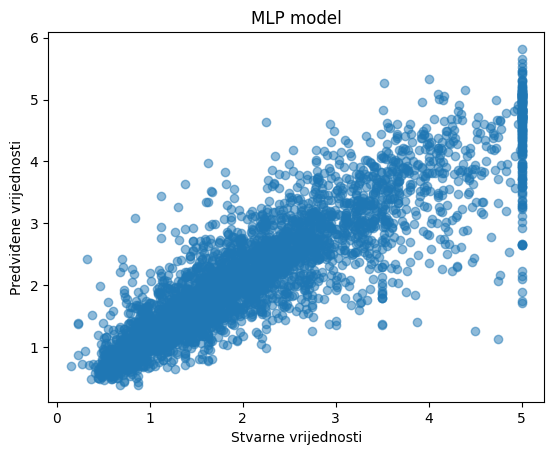

In [12]:
plt.scatter(y_test, pred_mlp, alpha=0.5)
plt.xlabel("Stvarne vrijednosti")
plt.ylabel("Predviđene vrijednosti")
plt.title("MLP model")
plt.show()

Vizualno provjeravamo koliko su predviđanja blizu stvarnih vrijednosti.

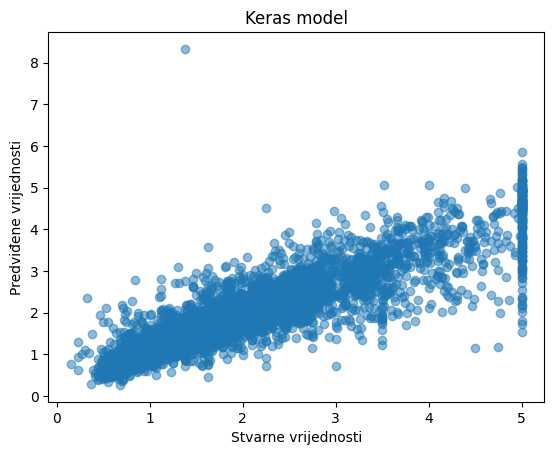

In [13]:
plt.scatter(y_test, pred_keras, alpha=0.5)
plt.xlabel("Stvarne vrijednosti")
plt.ylabel("Predviđene vrijednosti")
plt.title("Keras model")
plt.show()

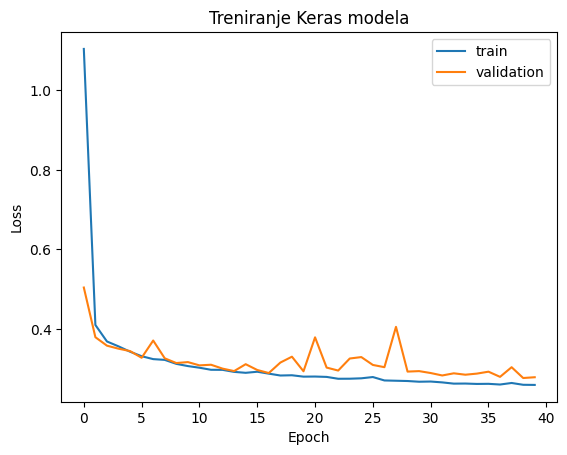

In [14]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Treniranje Keras modela")
plt.legend()
plt.show()

Ovdje pratimo kako model uči kroz vrijeme.
Ako validation loss raste to je znak overfittinga.

U ovom zadatku uspoređeni su MLPRegressor i Keras neuronska mreža.
Oba modela daju dobre rezultate, ali MLP model je pokazao nešto bolje performanse (manji RMSE i MAE, veći R²).
Keras model zahtijeva više vremena za treniranje, ali omogućuje veću fleksibilnost u dizajnu mreže.
Također, iz grafa gubitka možemo vidjeti kako model uči kroz epohe i eventualne znakove overfittinga.